<center>
    <h1>R kernel based on xeus</h1>
</center>

This notebook demonstrates R language support through explicit `%%R` magic cells, matching the xeus-x multi-language routing style.

In [1]:
%%R
R.version

               _                           
platform       wasm32-unknown-emscripten   
arch           wasm32                      
os             emscripten                  
system         wasm32, emscripten          
status                                     
major          4                           
minor          5.3                         
year           2026                        
month          03                          
day            11                          
svn rev        89597                       
language       R                           
version.string R version 4.5.3 (2026-03-11)
nickname       Reassured Reassurer         

# Builtin data structures

Vectors, lists, data frames 

In [2]:
%%R
# simple data structures
1:10
letters

 [1] "a" "b" "c" "d" "e" "f" "g" "h" "i" "j" "k" "l" "m" "n" "o" "p" "q" "r" "s"
[20] "t" "u" "v" "w" "x" "y" "z"

In [3]:
%%R
# lists
list(a = 42, b = 1:5, c = sample(LETTERS, 10))

$a
[1] 42

$b
[1] 1 2 3 4 5

$c
 [1] "P" "W" "L" "S" "R" "V" "H" "I" "N" "E"


In [4]:
%%R
# data frames
head(mtcars)

                   mpg cyl disp  hp drat    wt  qsec vs am gear carb
Mazda RX4         21.0   6  160 110 3.90 2.620 16.46  0  1    4    4
Mazda RX4 Wag     21.0   6  160 110 3.90 2.875 17.02  0  1    4    4
Datsun 710        22.8   4  108  93 3.85 2.320 18.61  1  1    4    1
Hornet 4 Drive    21.4   6  258 110 3.08 3.215 19.44  1  0    3    1
Hornet Sportabout 18.7   8  360 175 3.15 3.440 17.02  0  0    3    2
Valiant           18.1   6  225 105 2.76 3.460 20.22  1  0    3    1

In [5]:
%%R
# tibbles
suppressPackageStartupMessages({
    library(dplyr)
})

mtcars %>%
  group_by(cyl) %>%
  summarise(mpg = mean(mpg))

# A tibble: 3 × 2
    cyl   mpg
  <dbl> <dbl>
1     4  26.7
2     6  19.7
3     8  15.1

# Rich display
This is done differently than the reference `IRkernel` in that it does not automatically `display()` everything, but rather only prints the last expression from the cell. If we want a fancy display, we can use the `display()` function from `IRdisplay` which is automatically available: 

In [6]:
%%R
display(1:10)
display(list(a = 42, b = 1:5, c = sample(LETTERS, 10)))
display(head(mtcars))

 [1]  1  2  3  4  5  6  7  8  9 10

$a\n[1] 42\n\n$b\n[1] 1 2 3 4 5\n\n$c\n [1] "Z" "B" "S" "J" "U" "T" "P" "M" "C" "A"\n

                   mpg cyl disp  hp drat    wt  qsec vs am gear carb\nMazda RX4         21.0   6  160 110 3.90 2.620 16.46  0  1    4    4\nMazda RX4 Wag     21.0   6  160 110 3.90 2.875 17.02  0  1    4    4\nDatsun 710        22.8   4  108  93 3.85 2.320 18.61  1  1    4    1\nHornet 4 Drive    21.4   6  258 110 3.08 3.215 19.44  1  0    3    1\nHornet Sportabout 18.7   8  360 175 3.15 3.440 17.02  0  0    3    2\nValiant           18.1   6  225 105 2.76 3.460 20.22  1  0    3    1

We can also customize how a custom class is displayed.
We can add multiple representations by combining a [MIME type](https://en.wikipedia.org/wiki/Media_type) to the associated data.
The frontend will pick the "richest" one.

In [7]:
%%R
# Define some custom class
MyObj <- R6::R6Class(
  "MyObj",
  public = list(
    value = NULL,
    initialize = function(value) {
      self$value <- value
    }
  )
)

# Define which representation we decide to expose.
# Here plain text and HTML
mime_types.MyObj <- function(x) {
  c("text/plain", "text/html")
}

# Define the data to be returned with each MIME type.
mime_bundle.MyObj <- function(x, mimetypes = mime_types(x), ...) {
  list(
    data = list(
      "text/plain" = paste0("Check out MyObj: ", x$value),
      "text/html" = paste0("<div>Check out <b>MyObj</b>: ", x$value, "</div>")
    ),
    metadata = list()
  )
}

# Custom representation gets displayed automatically
MyObj$new(42)

<MyObj>
  Public:
    clone: function (deep = FALSE) 
    initialize: function (value) 
    value: 42

This works with advanced MIME types for image, sound and video too!

In [8]:
%%R
MyShape <- R6::R6Class(
  "MyShape",
  public = list(
    size = NULL,
    initialize = function(size = 80) {
      self$size <- size
    }
  )
)

mime_types.MyShape <- function(x) {
  c("text/plain", "image/svg+xml")
}

mime_bundle.MyShape <- function(x, mimetypes = mime_types(x), ...) {
  s <- x$size
  svg <- paste0(
    '<svg width="', s, '" height="', s, '" viewBox="0 0 ', s, ' ', s, '">',
    '<rect width="100%" height="100%" fill="white"/>',
    '<line x1="0" y1="0" x2="', s, '" y2="', s, '" stroke="red" stroke-width="4"/>',
    '<line x1="0" y1="', s, '" x2="', s, '" y2="0" stroke="blue" stroke-width="4"/>',
    '</svg>'
  )
  list(
    data = list(
      "text/plain" = paste0("<MyShape size=", s, ">"),
      "image/svg+xml" = svg
    ),
    metadata = list("image/svg+xml" = list(isolated = TRUE))
  )
}

MyShape$new()

<MyShape>
  Public:
    clone: function (deep = FALSE) 
    initialize: function (size = 80) 
    size: 80

# plots

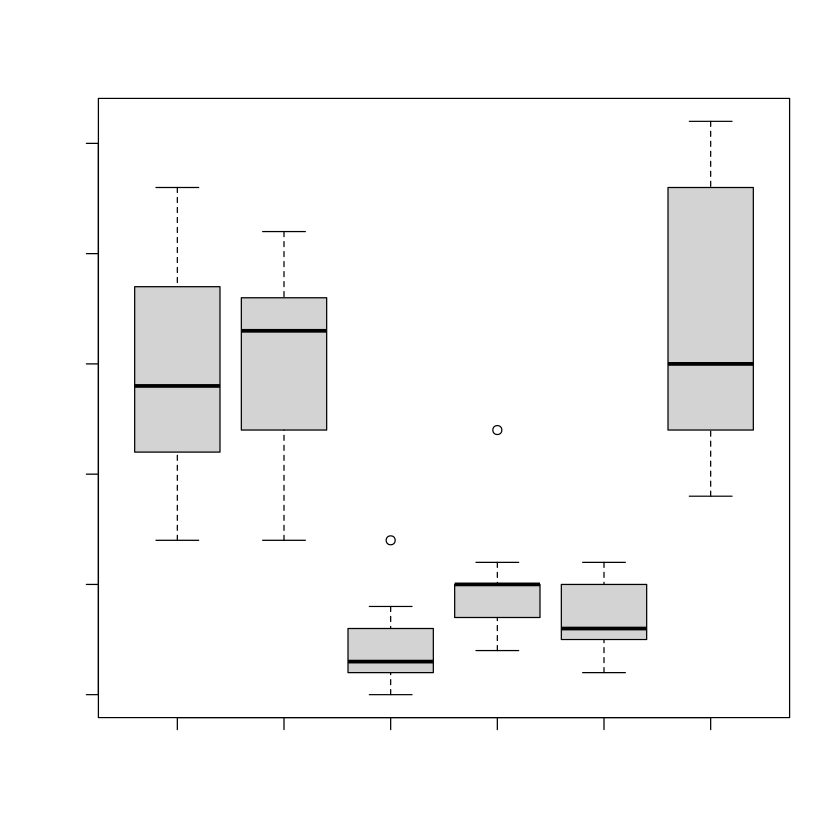

In [9]:
%%R
# base graphics
boxplot(count ~ spray, data = InsectSprays, col = "lightgray")

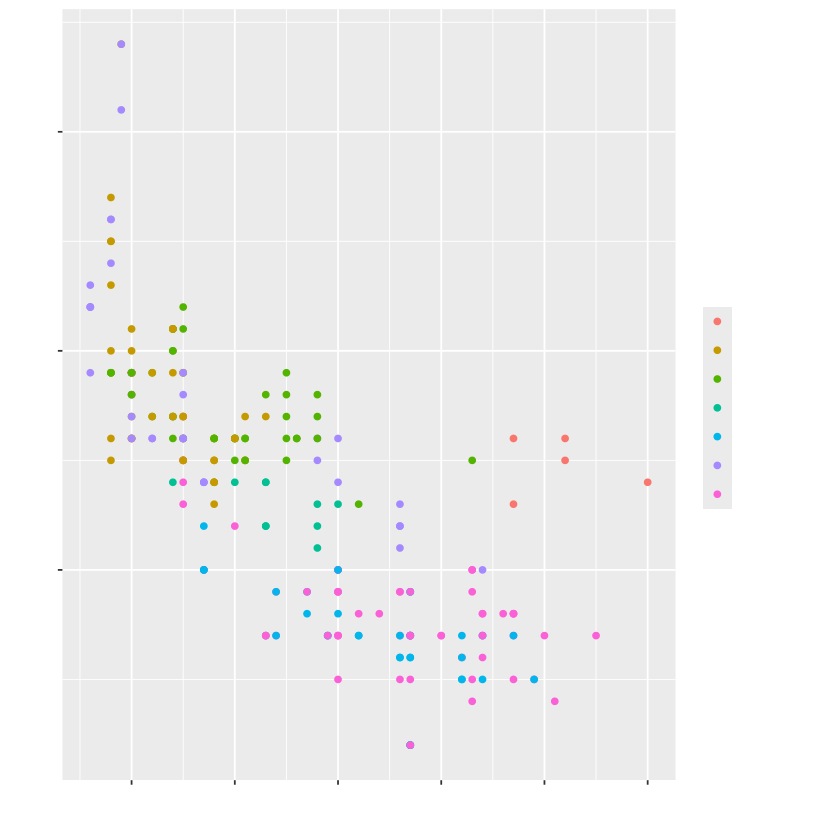

In [10]:
%%R
# ggplot2
library(ggplot2)

ggplot(mpg, aes(displ, hwy, colour = class)) + 
  geom_point()